In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

**<font size="6" color="red">ch2. 한글 형태소 분석 </font>**
# 1. 자연어 처리
- 자연어 : 일상적인 언어
- 인공어 : 사람들이 필요에 의해 만든 언어(ex. 프로그래밍 언어)
- 자연어 처리 분야 : 
    * 자연어 이해 : 형태소 분석 -> postagging -> 
    * 자연어 생성 : RNN, LSTM, GRU, .... , encoder-decoder 알고리즘 -> 트랜스포머알고리즘
- 활용분야 : 트랜드 분석, 탐색적 분석, 맞춤법 검사, 번역기, 챗봇

# 2. 자연어 이해 처리 절차
- 전처리 : 단어, 어절 추출
- 분석 후보 생성 : 형태소 분리, 품사 태깅(pos tagging)
- 제약조건(불용어처리) : 규칙 확인
- 분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ...
# 3. 한글형태소 분석 엔진(Konlpy, ...)
- 공통기능 : morphs(형태소 나누기), nouns(명사추출), pos(형태소로 나누어 품사 태그)
- Konlpy (pip install konlpy)
    * HanNanum(한나눔) : 카이스트에서 만듦. 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수 및 Path 설정 필요)
    * KKma(꼬꼬마) : 서울대에서 만듦. 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수 및 Path 설정 필요)
    * Komoran(꼬모란)
    * Okt
- Mecab (pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양에서 사용가능. 다국어 바인딩 지원

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [6]:
text = '''
아름답지만 다소 복잡한 한국어는 
전세계에서 13번째로 많이 사용되는 언어입니다.
놀랍군요! 브라보!
나는 박진성 39세. 전화번호는 010-6787-3338.
예전에는 아리랑이라는 형태소 분석기를 사용했었습니다.
'''

## 3.1 HanNanum

- 구글에서 konlpy docs 검색 https://konlpy.org/
- api 메뉴 -> "Comparison between POS tagging classes"클릭 -> Korean POS tags comparison chart클릭

In [7]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size = 1024, # 차지하는 메모리 사이즈, 기본값 1024; '1g', '10m', ... / 최대 사이즈는 4기가
                   )
hannanum.analyze(text)  # 여러가지 태깅 후보들이 보여진다 / ntag=69

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('한', 'ncn')],
  [('복잡', 'ncps'), ('한', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]],
 [[('.', 'sf')], [('.', 'sy')]],
 [],
 [[('놀랍', 'paa'), ('군요', 'ef')], [('놀랍', 'paa'), ('군', 'ef'), ('요', 'jxf')]],
 [[('!', 'sf')]],
 [],
 [[('브라', 'ncn'), ('보', 'ncn')]],
 [[('!', 'sf')]],
 [],
 [[('나', 'ncn'), ('는', 'jxc')],
  [('나', 'npp'), ('는', 'jxc')],
  [('나', 'pvg'), ('는', 'etm')],
  [('나', 'px'), ('는', 'etm'

In [7]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.', '놀랍', '군', '요', '!', '브라보', '!', '나', '는', '박진성', '39세', '.', '전화번호', '는', '010-6787-3338', '.', '예전', '에는', '아리랑', '이', '라는', '형태소', '분석기', '를', '사용', '하', '었었습니다', '.']


In [8]:
# 명사만 추출 , 단 해당 명사가 어떤 종류인지는 안나온다
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어', '브라보', '나', '박진성', '39세', '전화번호', '010-6787-3338', '예전', '아리랑', '형태소', '분석기', '사용']


In [13]:
# 품사 태그
print(hannanum.pos(text, ntags=9))  # 품사 갯수 기본값 ntags=9

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('많', 'P'), ('이', 'X'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E'), ('.', 'S'), ('놀랍', 'P'), ('군', 'E'), ('요', 'J'), ('!', 'S'), ('브라보', 'N'), ('!', 'S'), ('나', 'N'), ('는', 'J'), ('박진성', 'N'), ('39세', 'N'), ('.', 'S'), ('전화번호', 'N'), ('는', 'J'), ('010-6787-3338', 'N'), ('.', 'S'), ('예전', 'N'), ('에는', 'J'), ('아리랑', 'N'), ('이', 'J'), ('라는', 'E'), ('형태소', 'N'), ('분석기', 'N'), ('를', 'J'), ('사용', 'N'), ('하', 'X'), ('었었습니다', 'E'), ('.', 'S')]


In [14]:
print(hannanum.pos(text, ntags=22))  # 품사 갯수 ntags=22

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF'), ('.', 'SF'), ('놀랍', 'PA'), ('군', 'EF'), ('요', 'JX'), ('!', 'SF'), ('브라보', 'NC'), ('!', 'SF'), ('나', 'NP'), ('는', 'JX'), ('박진성', 'NC'), ('39세', 'NN'), ('.', 'SF'), ('전화번호', 'NC'), ('는', 'JX'), ('010-6787-3338', 'NN'), ('.', 'SF'), ('예전', 'NC'), ('에', 'JC'), ('는', 'JX'), ('아리랑', 'NC'), ('이', 'JP'), ('라', 'EF'), ('는', 'ET'), ('형태소', 'NC'), ('분석기', 'NC'), ('를', 'JC'), ('사용', 'NC'), ('하', 'XS'), ('었었', 'EP'), ('습니다', 'EF'), ('.', 'SF')]


In [9]:
# 퀴즈1. text에서 형용사만 추출해보기
[(word, tag) for word, tag in hannanum.pos(text, ntags=22) if tag=='PA' ]


[('아름답', 'PA'), ('많', 'PA'), ('놀랍', 'PA')]

In [20]:
# 퀴즈2. text에서 명사만 추출해보기
[word for word in hannanum.nouns(text) ]
[word for word, tag in hannanum.pos(text, ntags=22) if tag=='NC' or\
                                                         tag=='NQ' or\
                                                         tag=='NB' or\
                                                         tag=='NP' or\
                                                         tag=='NN']
[word for word, tag in hannanum.pos(text, ntags=22)\
                         if tag in ('NC', 'NQ', 'NB', 'NP', 'NN') ]
[word for word, tag in hannanum.pos(text, ntags=22)\
                         if tag.startswith('N') ]

['복잡',
 '한국어',
 '전세계',
 '13',
 '번',
 '사용',
 '언어',
 '브라보',
 '나',
 '박진성',
 '39세',
 '전화번호',
 '010-6787-3338',
 '예전',
 '아리랑',
 '형태소',
 '분석기',
 '사용']

In [13]:
# 퀴즈3. text에서 보통명사만 추출해보기
[word for word, tag in hannanum.pos(text, ntags=22) if tag=='NC' ]

['복잡',
 '한국어',
 '전세계',
 '사용',
 '언어',
 '브라보',
 '박진성',
 '전화번호',
 '예전',
 '아리랑',
 '형태소',
 '분석기',
 '사용']

## 3.2 KKma (꼬꼬마)

In [21]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
           max_heap_size=1024 # '4m', '4g'
           )
# 형태소 분리
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.', '놀랍', '군요', '!', '브라보', '!', '나', '는', '박진', '성', '39', '세', '.', '전화번호', '는', '010-6787', '-3338', '.', '예전', '에', '는', '아리랑', '이', '라는', '형태소', '분석기', '를', '사용하', '었', '었', '습니다', '.']


In [22]:
# 명사 추출
print(kkma.nouns(text))

['한국어', '전세계', '13', '13번째', '번째', '사용', '언어', '나', '박진', '39', '39세', '세', '전화번호', '-3338', '예전', '아리랑', '형태소', '분석기']


In [23]:
# 품사 태깅, kkma는 ntags 지정 불가. 기본 56
print(kkma.pos(text))

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('ㄴ', 'ETD'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF'), ('놀랍', 'VA'), ('군요', 'EFI'), ('!', 'SF'), ('브라보', 'IC'), ('!', 'SF'), ('나', 'NP'), ('는', 'JX'), ('박진', 'NNG'), ('성', 'XSN'), ('39', 'NR'), ('세', 'NNM'), ('.', 'SF'), ('전화번호', 'NNG'), ('는', 'JX'), ('010-6787', 'OL'), ('-3338', 'NR'), ('.', 'SF'), ('예전', 'NNG'), ('에', 'JKM'), ('는', 'JX'), ('아리랑', 'NNG'), ('이', 'VCP'), ('라는', 'ETD'), ('형태소', 'NNG'), ('분석기', 'NNG'), ('를', 'JKO'), ('사용하', 'VV'), ('었', 'EPT'), ('었', 'EPT'), ('습니다', 'EFN'), ('.', 'SF')]


In [25]:
# 명사 추출
tagged_text = kkma.pos(text)
print([token for token, tag in tagged_text if tag.startswith('N')])

['한국어', '전세계', '13', '번째', '사용', '언어', '나', '박진', '39', '세', '전화번호', '-3338', '예전', '아리랑', '형태소', '분석기']


## 3.3 Komoran

In [26]:
from konlpy.tag import Komoran
komoran = Komoran(max_heap_size=1024)
komoran.morphs(text)

['아름답',
 '지만',
 '다소',
 '복잡',
 '하',
 'ㄴ',
 '한국어',
 '는',
 '전',
 '세계',
 '에서',
 '13',
 '번',
 '째',
 '로',
 '많이',
 '사용',
 '되',
 '는',
 '언어',
 '이',
 'ㅂ니다',
 '.',
 '놀랍',
 '군요',
 '!',
 '브라보',
 '!',
 '나',
 '는',
 '박진성',
 '39',
 '세',
 '.',
 '전화번호',
 '는',
 '010',
 '-',
 '6787',
 '-',
 '3338',
 '.',
 '예전',
 '에',
 '는',
 '아리랑',
 '이',
 '라는',
 '형태소',
 '분석기',
 '를',
 '사용',
 '하',
 '았었',
 '습니다',
 '.']

In [27]:
komoran.pos(text)

[('아름답', 'VA'),
 ('지만', 'EC'),
 ('다소', 'MAG'),
 ('복잡', 'XR'),
 ('하', 'XSA'),
 ('ㄴ', 'ETM'),
 ('한국어', 'NNP'),
 ('는', 'JX'),
 ('전', 'NNG'),
 ('세계', 'NNG'),
 ('에서', 'JKB'),
 ('13', 'SN'),
 ('번', 'NNB'),
 ('째', 'XSN'),
 ('로', 'JKB'),
 ('많이', 'MAG'),
 ('사용', 'NNG'),
 ('되', 'XSV'),
 ('는', 'ETM'),
 ('언어', 'NNG'),
 ('이', 'VCP'),
 ('ㅂ니다', 'EF'),
 ('.', 'SF'),
 ('놀랍', 'VA'),
 ('군요', 'EF'),
 ('!', 'SF'),
 ('브라보', 'NNP'),
 ('!', 'SF'),
 ('나', 'NP'),
 ('는', 'JX'),
 ('박진성', 'NNP'),
 ('39', 'SN'),
 ('세', 'NNB'),
 ('.', 'SF'),
 ('전화번호', 'NNP'),
 ('는', 'JX'),
 ('010', 'SN'),
 ('-', 'SW'),
 ('6787', 'SN'),
 ('-', 'SW'),
 ('3338', 'SN'),
 ('.', 'SF'),
 ('예전', 'NNG'),
 ('에', 'JKB'),
 ('는', 'JX'),
 ('아리랑', 'NNP'),
 ('이', 'VCP'),
 ('라는', 'ETM'),
 ('형태소', 'NNP'),
 ('분석기', 'NNG'),
 ('를', 'JKO'),
 ('사용', 'NNG'),
 ('하', 'XSV'),
 ('았었', 'EP'),
 ('습니다', 'EF'),
 ('.', 'SF')]

In [28]:
komoran.nouns(text)

['한국어',
 '전',
 '세계',
 '번',
 '사용',
 '언어',
 '브라보',
 '박진성',
 '세',
 '전화번호',
 '예전',
 '아리랑',
 '형태소',
 '분석기',
 '사용']

In [30]:
# 일반명사(NNG), 고유명사(NNP)만 추출
[token for token, tag in komoran.pos(text) if tag in ('NNG', 'NNP')]

['한국어',
 '전',
 '세계',
 '사용',
 '언어',
 '브라보',
 '박진성',
 '전화번호',
 '예전',
 '아리랑',
 '형태소',
 '분석기',
 '사용']

## 3.4 Okt(Open Korean Text;Twitter)
- konlpy v0.4.5부터 Twitter -> Okt

In [31]:
import konlpy
konlpy.__version__

'0.6.0'

In [38]:
from konlpy.tag import Twitter, Okt
# okt = Twitter() # 경고 뜸. okt로 하라고
okt = Okt()
print('구 추출 : ', okt.phrases(text))
print('형태소 추출 : ', okt.morphs(text))
print('명사 추출 : ', okt.nouns(text))
tagged_text = okt.pos(text) # ntag = 19 기본값
print('품사 태깅 : ', tagged_text) 
print('품사 태깅을 이용한 명사 추출 : ', 
      [token for token, tag in tagged_text if tag=='Noun'])

구 추출 :  ['다소', '다소 복잡한 한국어', '전세계', '13번째', '사용', '사용되는 언어', '브라보', '박진성', '박진성 39세', '전화번호', '010-6787', '3338', '예전', '아리랑', '형태소', '형태소 분석', '형태소 분석기를 사용', '한국어', '13', '번째', '언어', '39', '분석']
형태소 추출 :  ['\n', '아름답지만', '다소', '복잡한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '.', '\n', '놀랍군요', '!', '브라보', '!', '\n', '나', '는', '박진성', '39', '세', '.', '전화번호', '는', '010-6787', '-', '3338', '.', '\n', '예전', '에는', '아리랑', '이라는', '형태소', '분석', '기를', '사용', '했었습니다', '.', '\n']
명사 추출 :  ['다소', '한국어', '전세계', '번', '사용', '언어', '브라보', '나', '박진성', '세', '전화번호', '예전', '아리랑', '형태소', '분석', '사용']
품사 태깅 :  [('\n', 'Foreign'), ('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡한', 'Adjective'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation'), ('\n', 'Foreign'), ('놀랍군요', 'Verb'), ('!', 'Punctua

## 3.5 MeCab
- pip install python-mecab-ko
- C++로 만들어 가볍고 빠름

In [40]:
from mecab import MeCab
mecab = MeCab() # 힙메모리 지정 안됨
print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecab.pos(text)
print('품사 태깅 :', mecab.pos(text))
print('품사 태깅을 이용한 명사 추출 :', mecab.pos(text))

형태소 추출 : ['아름답', '지만', '다소', '복잡', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다', '.', '놀랍', '군요', '!', '브라보', '!', '나', '는', '박진성', '39', '세', '.', '전화', '번호', '는', '010', '-', '6787', '-', '3338', '.', '예전', '에', '는', '아리랑', '이', '라는', '형태소', '분석기', '를', '사용', '했었', '습니다', '.']


# 4. 말뭉치(corpus)

In [41]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [44]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [56]:
# 한글 말뭉치
from konlpy.corpus import kolaw
data = kolaw.open('constitution.txt').read() # read() : 전체 불러오기, readlines() : \n 기준 한줄씩 리스트로 전체 불러오기
data

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제·사회·문화의 모든 영역에 있어서 각인의 기회를 균등히 하고, 능력을 최고도로 발휘하게 하며, 자유와 권리에 따르는 책임과 의무를 완수하게 하여, 안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서 1948년 7월 12일에 제정되고 8차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다.\n\n       제1장 총강\n  제1조 ① 대한민국은 민주공화국이다.\n②대한민국의 주권은 국민에게 있고, 모든 권력은 국민으로부터 나온다.\n  제2조 ① 대한민국의 국민이 되는 요건은 법률로 정한다.\n②국가는 법률이 정하는 바에 의하여 재외국민을 보호할 의무를 진다.\n  제3조 대한민국의 영토는 한반도와 그 부속도서로 한다.\n  제4조 대한민국은 통일을 지향하며, 자유민주적 기본질서에 입각한 평화적 통일 정책을 수립하고 이를 추진한다.\n  제5조 ① 대한민국은 국제평화의 유지에 노력하고 침략적 전쟁을 부인한다.\n②국군은 국가의 안전보장과 국토방위의 신성한 의무를 수행함을 사명으로 하며, 그 정치적 중립성은 준수된다.\n  제6조 ① 헌법에 의하여 체결·공포된 조약과 일반적으로 승인된 국제법규는 국내법과 같은 효력을 가진다.\n②외국인은 국제법과 조약이 정하는 바에 의하여 그 지위가 보장된다.\n  제7조 ① 공무원은 국민전체에 대한 봉사자이며, 국민에 대하여 책임을 진다.\n②공무원의 신분과 정치적 중립성은 법률이 정하는 바에 의하여 보장된다.\n  제8조 ① 정

In [63]:
# 말뭉치에서 단어 추출(특수문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[\w]{2,}')
words = ret.tokenize(emma)

# 명사만 추출(고유명사 제외)
emma_tags = pos_tag(words)
nouns_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS')]
print('추출된 명사 개수 :', len(nouns_list), len(set(nouns_list)))
print('nouns_list : ', nouns_list[:10])

# 추출된 명사를 한 리스트로 만들기
emma_noun = ' '.join(nouns_list)
print('워드클라우드에 필요한 내용 :', emma_noun[:100])

추출된 명사 개수 : 22362 3498
nouns_list :  ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']
워드클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


# 5. 워드클라우드

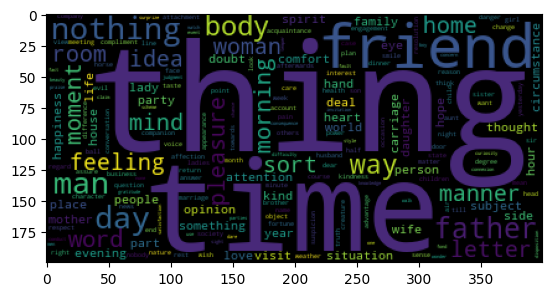

In [68]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordc = WordCloud()
wordc.generate(emma_noun)
plt.imshow(wordc)
plt.show()

### 컬러맵
- https://matplotlib.org/stable/users/explain/colors/colormaps.html

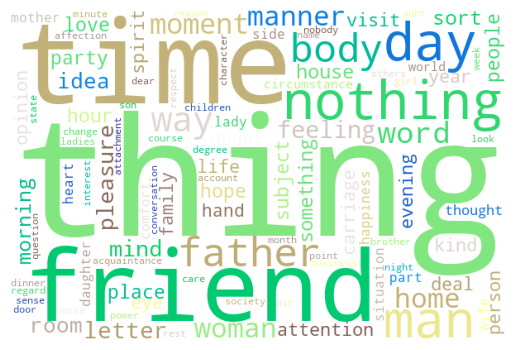

In [78]:
wordcloud = WordCloud(width=600, height= 400, # font_path='',
                     background_color='white',
                     max_words=100, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='terrain',  # 글씨 컬러맵 
                     max_font_size= 200,  
                     min_font_size= 10    
                     )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [106]:
%%time
# 한글 말뭉치 data로 워드 클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
noun_list = analyzer.nouns(data)
# 한나눔 noun_list2 = [word for word, tag in analyzer.pos(data, ntags=22) if tag in ('NC', 'NQ')]
noun_list2 = [word for word, tag in analyzer.pos(data) if tag in ('NNG', 'NNP')]
print(noun_list[:20])
print(noun_list2[:20])
data_noun = ' '.join(noun_list2)
print(data_noun[:100])

['대한민국', '헌법', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국', '임시', '정부', '법통', '불의', '항거', '민주', '이념', '계승', '조국', '민주', '개혁']
['대한민국', '헌법', '역사', '전통', '국민', '운동', '건립', '대한민국', '임시', '정부', '법통', '불의', '항거', '민주', '이념', '계승', '조국', '민주', '개혁', '평화']
대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타
CPU times: total: 797 ms
Wall time: 807 ms


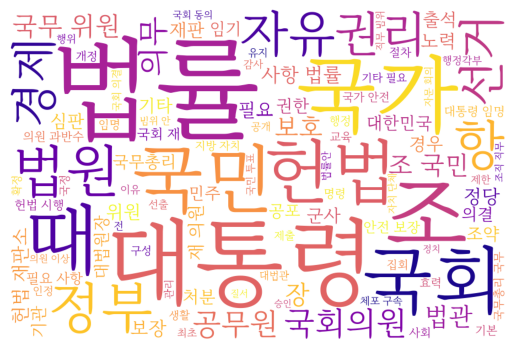

In [110]:
# 워드 클라우드 만들기
wordcloud = WordCloud(width=900, height= 600, 
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=100, # 표시될 단어의 최대 갯수
                     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='plasma',  # 글씨 컬러맵 
                     max_font_size= 200,  
                     min_font_size= 10,
                     # random_state= 4  # 랜덤 시드값 
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [115]:
# 불용어 처리(불용어 지정 + 불용어 사전)
from wordcloud import STOPWORDS  
불용어 = STOPWORDS | {'대통령', '법률', '조', '항'}  # | 집합 합연산자
# STOPWORDS 는 영어들로 이뤄져있어서 같이 하는게 의미가 없다.
불용어 = {'대통령', '법률', '조', '항'} 
불용어 = set(('대통령', '법률', '조', '항'))
불용어

{'대통령', '법률', '조', '항'}

(468, 720, 3)

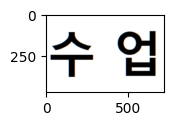

In [132]:
# 마스킹 : 워드클라우드 이미지가 지정된 이미지에 맞도록 설정 
import cv2
mask = cv2.imread('data/test.png'    # 이미지를 넘파이 배열로 읽어 변수에 저장
                  #, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(3,1))
plt.imshow(mask)
mask.shape

(468, 720, 3)

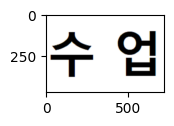

In [135]:
from PIL import Image
import numpy as np
img = Image.open('data/test.png')  # 이미지를 변수에 저장
mask = np.array(img)     # 이미지를 넘파이 배열로 변경
plt.figure(figsize=(3,1))
plt.imshow(mask)
mask.shape

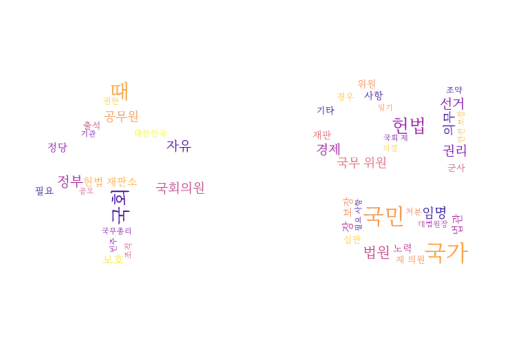

In [136]:
# 워드 클라우드 만들기
wordcloud = WordCloud(width=900, height= 600, 
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=100, # 표시될 단어의 최대 갯수
                     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='plasma',  # 글씨 컬러맵 
                     max_font_size= 200,  
                     min_font_size= 10,
                     # random_state= 4  # 랜덤 시드값
                     stopwords=불용어,   # 불용어 처리. 불용어는 set 구조
                     mask=mask    
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1600, 1600, 3)


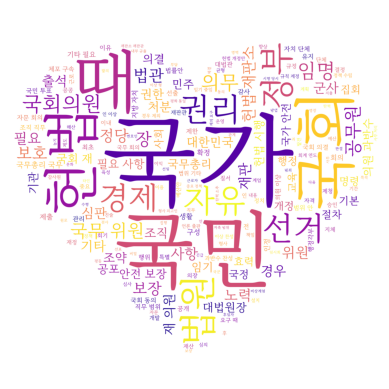

<Figure size 1500x600 with 0 Axes>

In [151]:
mask1 = cv2.imread('data/heart.jpg' )   # 이미지를 넘파이 배열로 읽어 변수에 저장
print(mask1.shape)
wordcloud = WordCloud(
                    # width=1400, height= 800,  # plt.figure(figsize=(15,6)) 로 사이즈를 조정하려면 이걸 빼야한다
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=200, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='plasma',  # 글씨 컬러맵 
                     # max_font_size= 300,  
                     # min_font_size= 10,
                     # random_state= 4  # 랜덤 시드값
                     stopwords=불용어,   # 불용어 처리. 불용어는 set 구조
                     mask=mask1    
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.figure(figsize=(15,6))
plt.show()

(1124, 720, 3)


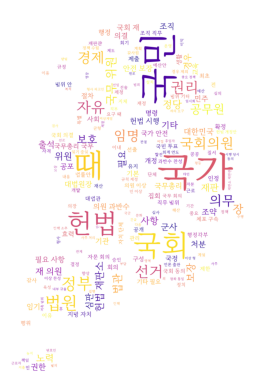

<Figure size 1500x1000 with 0 Axes>

In [150]:
mask3 = cv2.imread('data/south_korea.png')
print(mask3.shape)
wordcloud = WordCloud(
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=200, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='plasma',  # 글씨 컬러맵 
                     stopwords=불용어,   # 불용어 처리. 불용어는 set 구조
                     mask=mask3    
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.figure(figsize=(15,10))
plt.show()

(241, 257, 3)


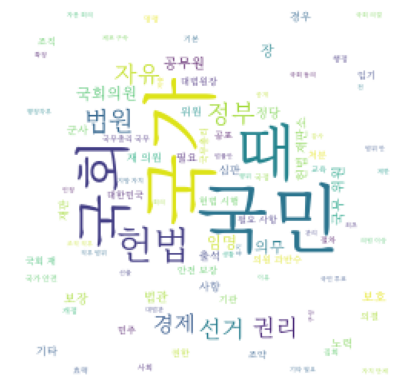

<Figure size 1500x1000 with 0 Axes>

In [149]:
mask4 = cv2.imread('data/test2.jpg')
print(mask4.shape)
wordcloud = WordCloud(
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=200, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='viridis',  # 글씨 컬러맵 
                     stopwords=불용어,   # 불용어 처리. 불용어는 set 구조
                     mask=mask4    
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.figure(figsize=(15,10))
plt.show()

In [162]:
# 비교 PIL.Image 이용시
img5 = Image.open('data/test.png')  # 이미지를 변수에 저장
mask5 = np.array(img5)     # 이미지를 넘파이 배열로 변경
print('원본이미지의 채널에 따라 3채널 : ', mask5.shape)
img6 = Image.open('data/south_korea.png') 
mask6 = np.array(img6)    
print('원본이미지의 채널에 따라 1채널 : ', mask6.shape, '=> 3채널로 만들어줘야 함')
img7 = Image.open('data/test3.png') 
mask7 = np.array(img7)    
print('원본이미지의 채널에 따라 1채널 : ', mask7.shape, '=> 3채널로 만들어줘야 함')

원본이미지의 채널에 따라 3채널 :  (468, 720, 3)
원본이미지의 채널에 따라 1채널 :  (1124, 720) => 3채널로 만들어줘야 함
원본이미지의 채널에 따라 1채널 :  (900, 900) => 3채널로 만들어줘야 함


In [165]:
# convert('RGB') : 1채널 이미지파일 -> 3채널
# convert('RGBA') : 1채널 이미지파일 -> 4채널(RGB+투명도채널)
img8 = Image.open('data/south_korea.png').convert('RGB') 
mask8 = np.array(img8)    
print(f'convert(\'RGB\')를 활용해 채녈 변경 : {mask6.shape} => {mask8.shape}')

convert('RGB')를 활용해 채녈 변경 : (1124, 720) => (1124, 720, 3)


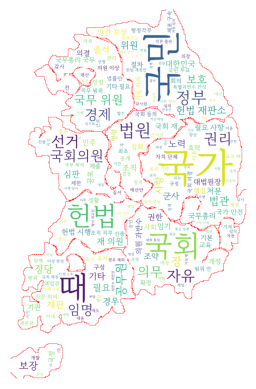

In [175]:
wordcloud = WordCloud(width=1000, height= 1000,
                     font_path='C:/Windows/Fonts/MaruBuri-Regular.ttf',
                     background_color='white',
                     max_words=200, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정, 기본은 'auto', 0~1 사이
                     colormap='viridis',  # 글씨 컬러맵 
                     stopwords=불용어,   # 불용어 처리. 불용어는 set 구조
                     mask=mask8,
                     contour_color='red',  # 내부 경계선
                     contour_width=1
                
                     )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
# plt.figure(figsize=(15,10))
plt.show()

In [176]:
# 생성된 워드클라우드 저장
wordcloud.to_file('korea.jpg')

In [179]:
%config InlineBackend.figure_format='retina'  
#한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False)  # 축의 - 깨짐 방지
# 경고 메세지 안보이게
import warnings
warnings.filterwarnings(action='ignore')

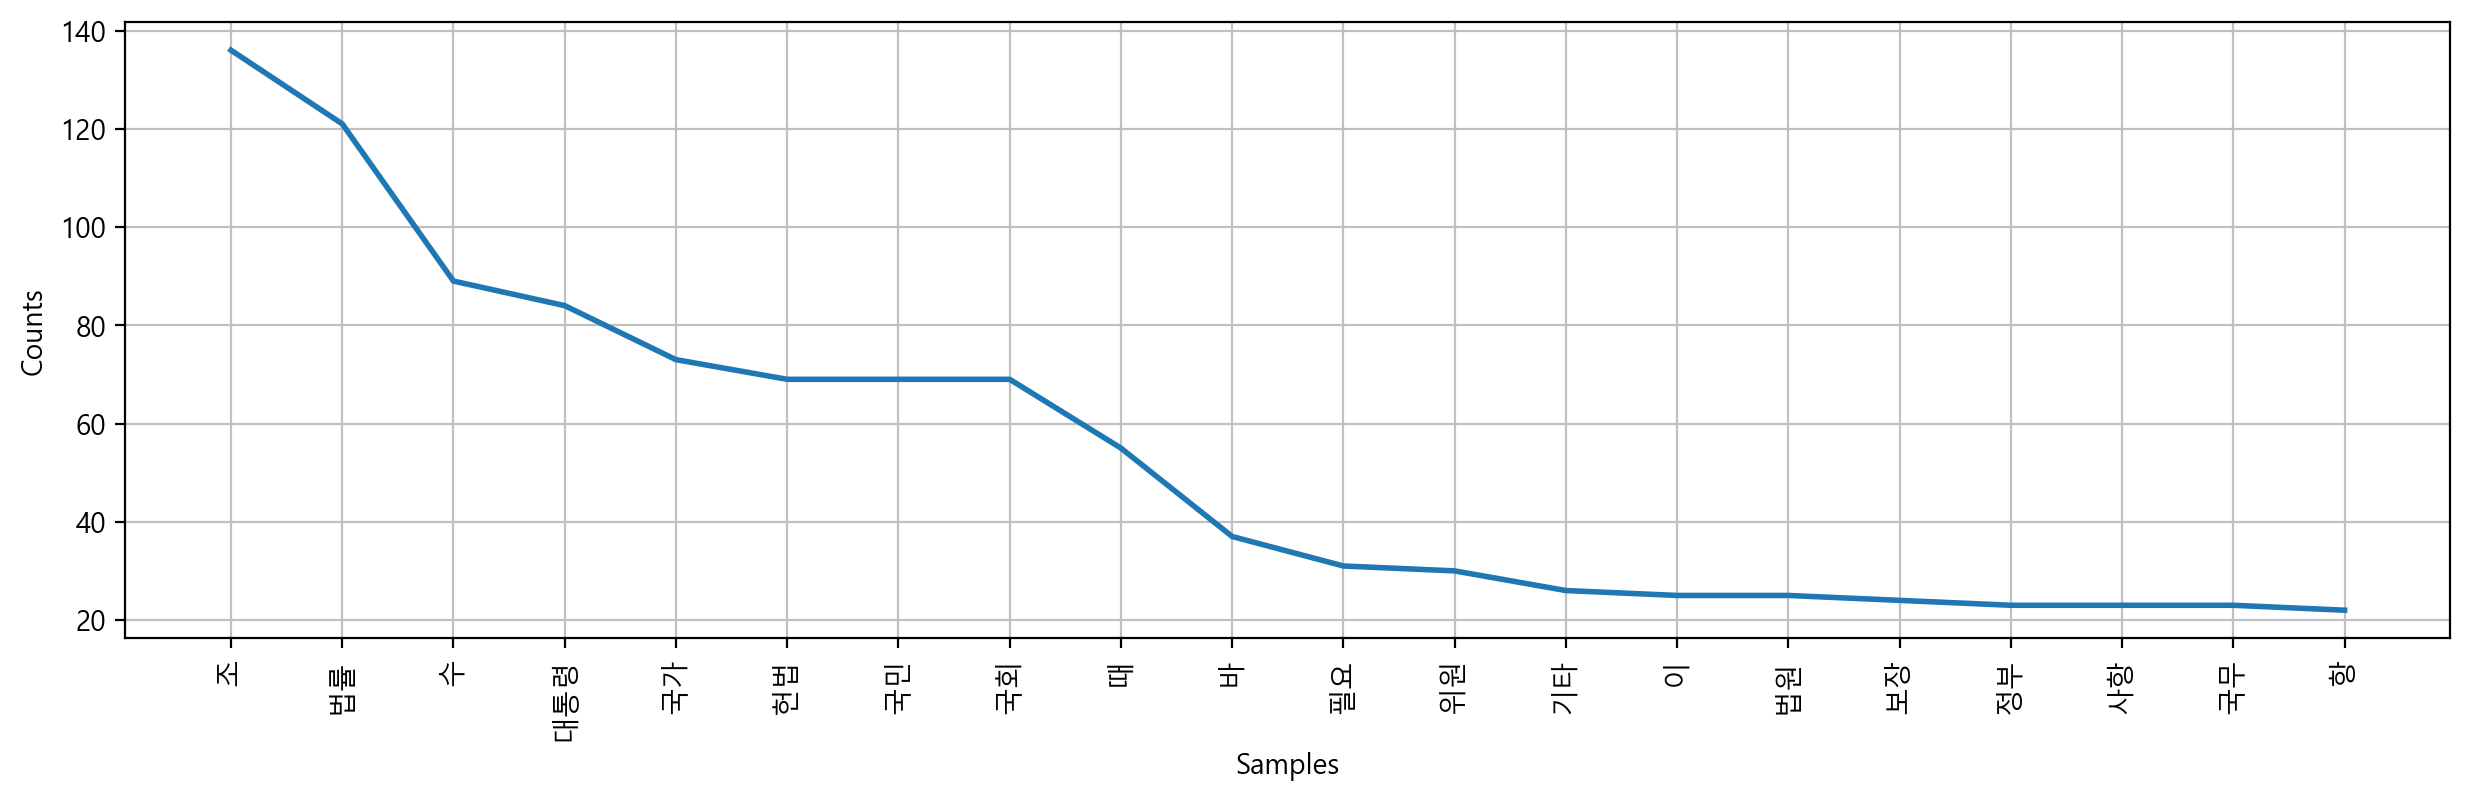

In [188]:
# 단어의 빈도수 시각화(nltk.Text 객체를 이용)
import matplotlib.pyplot as plt
import nltk
data_text = nltk.Text(noun_list)
plt.figure(figsize=(15,4))
text.plot(20)
plt.show()
# 그래프 커스텀에는 한계가 있음

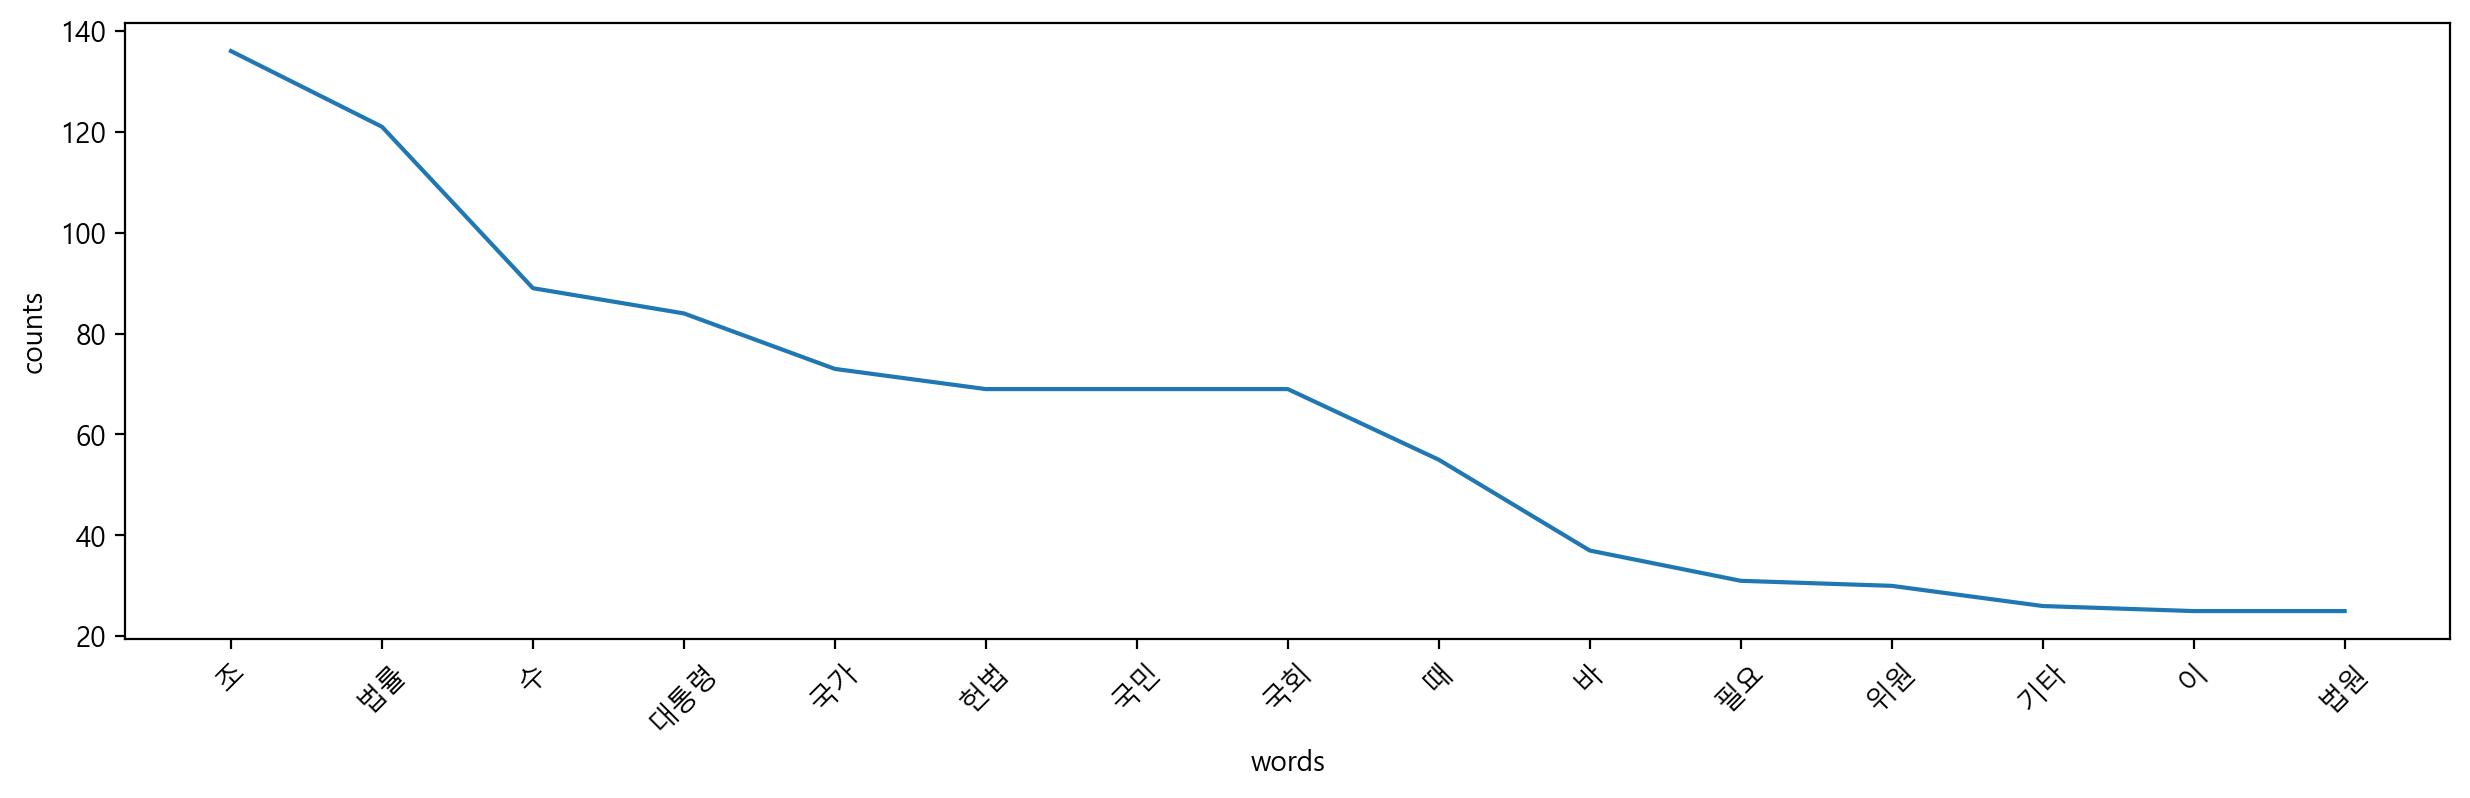

In [190]:
# 변수를 따로 추출하여 그래프를 그림
words, counts = zip(*data_text.vocab().most_common(15))
plt.figure(figsize=(15,4))
plt.plot(words, counts)
plt.xticks(rotation=45)
plt.xlabel('words')
plt.ylabel('counts')
plt.show()

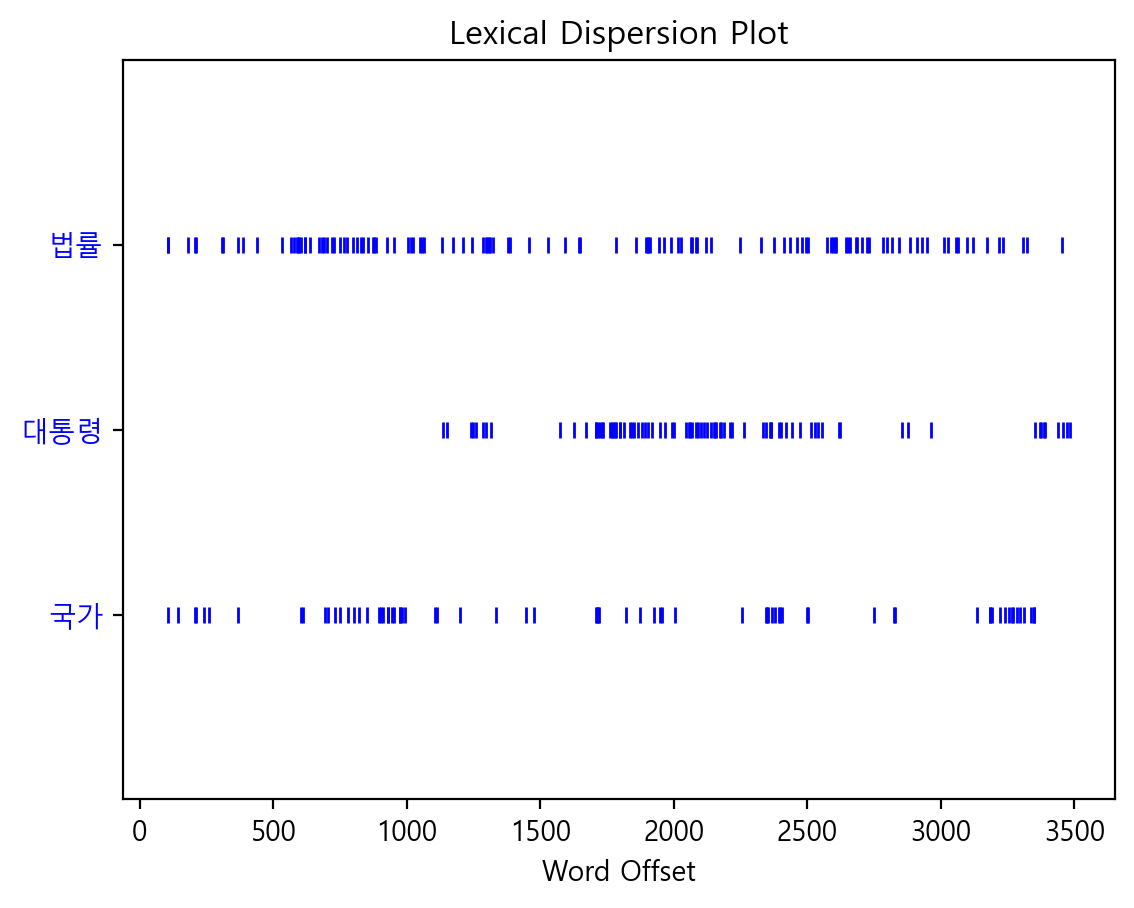

In [191]:
data_text.dispersion_plot(['법률', '대통령', '국가'])

# 6. 워드 임베딩
- 단어간 벡터를 계산 -> 단어간 유사성 도출

In [198]:
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, 'xml')
link_el = soup.select('item link')
link_list = [el.text for el in link_el]
len(link_list)

20

In [224]:
# 각 link 들의 뉴스 기사 -> 명사만 -: 아래와 같은 형태로 만들어져야함
'''
[['등촌', '재건축', '명사1',...], 
['캠핑장', '재건축', '명사2', ...],
[...],[...], ...]
'''
from mecab import MeCab
from konlpy.tag import Kkma
mecab = MeCab()
kkma = Kkma()
news1= []
news2= []

for link in link_list:
    # print(link, '에 가서 (title, desc)를 가져온다')
    response = requests.get(link)
    # print(response.status_code)  # 200 : 정상 접속
    news_soup = BeautifulSoup(response.text, "html.parser")
    # title = news_soup.select_one('span.MuiTypography-root.MuiTypography-inherit.e2d6xgw0.my-o2xdzg')
    title = news_soup.select_one('title').text
    desc = str(news_soup.select_one('meta[name="description"]'))
    # print(title) 
    불용어 = {'뉴스', '앵커'}
    noun_list1 = [ word for word in mecab.nouns(title + ' ' + desc ) if word not in 불용어]
    noun_list2 = [ word for word in kkma.nouns(title + ' ' + desc ) if word not in 불용어]    
    news1.append(noun_list1) 
    news2.append(noun_list2) 
print(news1[:2])
print(news2[:2])

[['둔촌', '주공', '전세', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '재건축', '둔촌', '주공', '아파트', '입주', '다음', '달', '말', '시작', '규모', '입주', '전세', '매물', '현장'], ['실제', '캠', '핑장', '관리', '소홀', '캠', '핑장', '예약', '때', '예약', '플랫폼', '사진', '땐', '기대', '사진', '당황', '분', '캠', '핑장']]
[['촌', '촌주공', '주공', '전', '홍수', '예상', '눈치', '눈치게임', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '아파트', '입주', '다음', '말', '대규모', '전세', '전세매물', '매물', '현장'], ['실제', '완전', '사기', '캠핑', '캠핑장', '장', '관리', '소홀', '예약', '때', '플랫폼', '사진', '기대', '당황', '분']]


In [239]:
# rss의 타이틀과 디스크립션 - > 명사 추출 => 워드임베딩(단어간 거리 계산)
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, 'xml')
items = soup.find_all('item')
news= []

for item in items:
    title = item.select_one('title').text
    description = item.find('description').text
    # print(item)
    #print(title)
    #print(description)
    article = title+' '+description.replace('[앵커]', ' ')
    noun_list1 = kkma.nouns(article)
    noun_list2 = [word for word, tag in kkma.pos(article) if tag in ('NNG', 'NNP')]
    print(noun_list1)
    print(noun_list2)
    news.append(noun_list2)
news[:3]
# 여기까지 명사 추출

['촌', '촌주공', '주공', '전', '홍수', '예상', '눈치', '눈치게임', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '아파트', '입주', '다음', '말', '대규모', '전세', '전세매물', '매물', '현장', '분위기', '이']
['촌', '주공', '전', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '촌', '주공', '아파트', '입주', '다음', '말', '시작', '대규모', '입주', '전세', '매물', '현장', '분위기', '이']
['실제', '완전', '사기', '캠핑', '캠핑장', '장', '관리', '소홀', '예약', '때', '플랫폼', '사진', '불만', '경우', '앞', '책임', '강화', '아람', '기자', '인터넷', '카페']
['실제', '완전', '사기', '캠핑', '장', '관리', '소홀', '캠핑', '장', '예약', '때', '예약', '플랫폼', '사진', '실제', '불만', '경우', '앞', '예약', '플랫폼', '책임', '강화', '아람', '기자', '기자', '인터넷', '카페']
['요즘', '끼', '편의점', '정도', '정도일', '일', '줄', '2', '2만', '만', '원', '육박', '점심', '점심값', '값', '도시락', '때', '7000', '7000원', '식비', '부담', '아람', '기자', '서울', '한']
['요즘', '끼', '편의점', '정도', '일', '줄', '육박', '점심', '값', '편의점', '도시락', '끼', '때', '편의점', '도시락', '식비', '부담', '아람', '기자', '기자', '서울', '한']
['오늘', '겠다', '말', '이유', '편의점', '도시락', '7', '7천원', '천', '원', '시대', '주머니', '직장인', '자취생', '눈앞', '아

[['촌',
  '주공',
  '전',
  '홍수',
  '예상',
  '눈치',
  '게임',
  '시작',
  '단군',
  '이래',
  '최대',
  '규모',
  '건축',
  '불리',
  '촌',
  '주공',
  '아파트',
  '입주',
  '다음',
  '말',
  '시작',
  '대규모',
  '입주',
  '전세',
  '매물',
  '현장',
  '분위기',
  '이'],
 ['실제',
  '완전',
  '사기',
  '캠핑',
  '장',
  '관리',
  '소홀',
  '캠핑',
  '장',
  '예약',
  '때',
  '예약',
  '플랫폼',
  '사진',
  '실제',
  '불만',
  '경우',
  '앞',
  '예약',
  '플랫폼',
  '책임',
  '강화',
  '아람',
  '기자',
  '기자',
  '인터넷',
  '카페'],
 ['요즘',
  '끼',
  '편의점',
  '정도',
  '일',
  '줄',
  '육박',
  '점심',
  '값',
  '편의점',
  '도시락',
  '끼',
  '때',
  '편의점',
  '도시락',
  '식비',
  '부담',
  '아람',
  '기자',
  '기자',
  '서울',
  '한']]

In [249]:
#워드 임베딩 (단어간 거리 계산)
# pip install gensim -> numpy를 참조함
from gensim.models import Word2Vec
model = Word2Vec(news,  # 학습데이터(2차원)
                window=10, # 각 단어의 좌우 10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습
                workers= -1, # 병렬처리 코어 수, -1 : 가용 코어 전체 사용
                )

In [243]:
model.wv.most_similar('아파트')

[('아연', 0.2122785449028015),
 ('불리', 0.19188855588436127),
 ('매출', 0.16693152487277985),
 ('성장률', 0.16677328944206238),
 ('기자', 0.15923377871513367),
 ('장', 0.15619252622127533),
 ('코스터', 0.1550060659646988),
 ('편의점', 0.1528114527463913),
 ('탓', 0.14976413547992706),
 ('예약', 0.14474642276763916)]

In [245]:
model.wv.most_similar('편의점', topn=3) # top3만

[('확인', 0.3698463439941406),
 ('대출', 0.21197080612182617),
 ('끼', 0.20174548029899597)]

KeyError: "Key '소홀' not present in vocabulary"